In [49]:
# # work on other do dataset
# bestseller
# Groceris

In [50]:
import pandas as ps
import numpy as nm
import matplotlib.pyplot as plt

In [51]:
#importing data:

df = ps.read_csv("../data/Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [52]:
df.info()

# print("\n\n",df.isnull().sum())       --  0 NULL in dataset

print("\n\nDuplicate Values: ", df.duplicated('Member_number').sum())
print("Duplicate Values: ", df.duplicated('Date').sum())
print("Duplicate Values: ", df.duplicated('itemDescription').sum())

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB


Duplicate Values:  34867
Duplicate Values:  38037
Duplicate Values:  38598


In [53]:
print("Independent variable, X:")
x = df.iloc[:, [0,1]].values     # User Rating, Reviews, Price, Year
print(x)

print("Dependent variable, Y:")
y = df.iloc[:, 2].values                 # Genre (Fiction / Non Fiction)
print(y)

Independent variable, X:
[[1808 '21-07-2015']
 [2552 '05-01-2015']
 [2300 '19-09-2015']
 ...
 [1097 '16-04-2014']
 [1510 '03-12-2014']
 [1521 '26-12-2014']]
Dependent variable, Y:
<StringArray>
[          'tropical fruit',               'whole milk',
                'pip fruit',         'other vegetables',
               'whole milk',               'rolls/buns',
         'other vegetables',               'pot plants',
               'whole milk',           'tropical fruit',
 ...
            'bottled water',    'fruit/vegetable juice',
               'rolls/buns', 'long life bakery product',
                      'oil',            'sliced cheese',
                    'candy',                 'cake bar',
    'fruit/vegetable juice',                 'cat food']
Length: 38765, dtype: str


In [54]:
# You may need to install this first (run once in a cell):
# pip install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

df = ps.read_csv("../data/Groceries_dataset.csv")

# Group by Member_number + Date = one transaction (basket)
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

print(transactions[:5])   # preview first 5 baskets

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = ps.DataFrame(te_array, columns=te.columns_)

# print(basket_df.head())

frequent_itemsets = apriori(basket_df, min_support=0.001, use_colnames=True)
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by='lift', ascending=False)
print(rules.head(10))

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]
      support                       itemsets
146  0.157923        frozenset({whole milk})
90   0.122101  frozenset({other vegetables})
109  0.110005        frozenset({rolls/buns})
123  0.097106              frozenset({soda})
147  0.085879            frozenset({yogurt})
110  0.069572   frozenset({root vegetables})
139  0.067767    frozenset({tropical fruit})
10   0.060683     frozenset({bottled water})
115  0.060349           frozenset({sausage})
28   0.053131      frozenset({citrus fruit})
                          antecedents                       consequents  \
236   frozenset({whole milk, yogurt})              frozenset({sausage})   
237              frozenset({sausage})   frozenset({whole milk, yogurt})   
234  frozenset({sausage, whole milk})               frozenset({yogurt})   
23

In [55]:
item_counts = df.groupby('itemDescription').size().reset_index(name='Count')
item_counts = item_counts.sort_values(by='Count', ascending=False)
print(item_counts)

print("Total unique items:", df['itemDescription'].nunique())

           itemDescription  Count
164             whole milk   2502
102       other vegetables   1898
122             rolls/buns   1716
138                   soda   1514
165                 yogurt   1334
..                     ...    ...
86         make up remover      5
5                     bags      4
4           baby cosmetics      3
79         kitchen utensil      1
114  preservation products      1

[167 rows x 2 columns]
Total unique items: 167


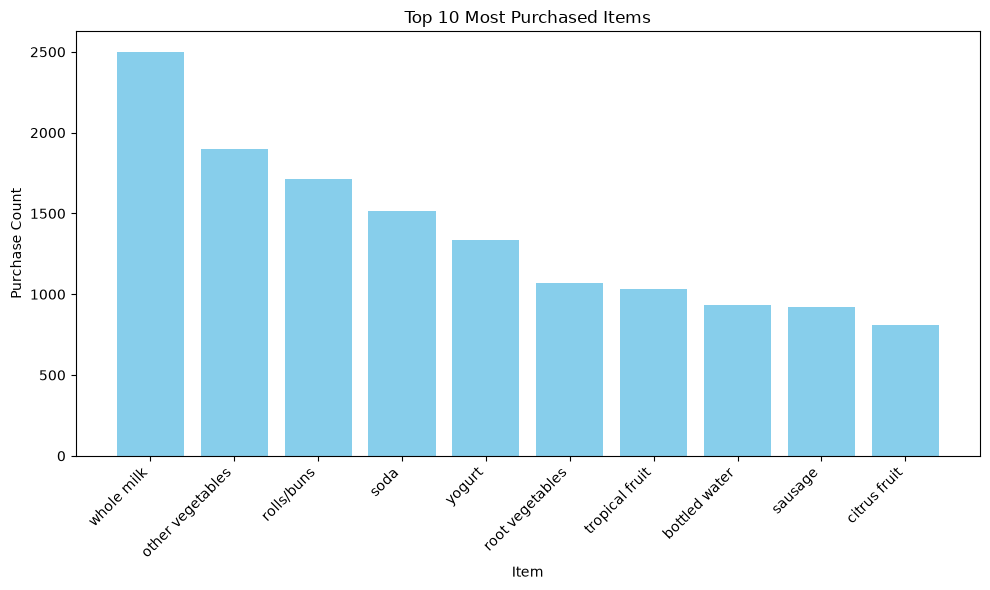

In [56]:
top_n = item_counts.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_n['itemDescription'], top_n['Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Item')
plt.ylabel('Purchase Count')
plt.title('Top 10 Most Purchased Items')
plt.tight_layout()
plt.show()